# Deep Learning Fundamentals Compared to Traditional ML

## 📚 Learning Objectives 

By completing this notebook (~20 min), you will:
- Train a small neural network on an MNIST subset and see accuracy
- Train a traditional ML classifier (e.g. logistic regression) on the same data
- Compare why we use deep learning for raw images instead of hand-crafted features

---

## 🌍 Real life 

**Where is this used?** Deep learning is used for **image recognition**, **speech**, **NLP** when we have raw high-dimensional data. Traditional ML (e.g. logistic regression, random forest) is still used for **tabular data** and when we have **hand-designed features** or limited data.

**In this notebook we use** a **feedforward neural network** to classify digits from **raw pixels** (MNIST). We use **deep learning** (instead of traditional ML on raw pixels) **because** the NN learns useful features from the data automatically; a simple classifier on raw pixels usually does worse unless we first engineer features.

**📌 Covers slide(s):** **08** — Fundamentals of Deep Learning (vs traditional ML). *Do this notebook after that slide in class.*

---

**Before starting:** Run the imports cell below.

## Theory (short) 

- **Traditional ML:** Often needs **hand-designed features** (e.g. edges, histograms). Model (e.g. logistic regression, SVM) then learns on top of those features.
- **Deep learning:** The network learns **features from raw data** (e.g. pixels) via layers; we don't hand-design them.
- **When to use which:** DL excels when we have **lots of data** and **raw signals** (images, text, audio). Traditional ML is strong for **tabular data**, small data, or when we already have good features.
- **We use a NN on raw pixels here** instead of only logistic regression on raw pixels because the NN can learn non-linear boundaries and feature hierarchies.

**The steps below put this theory into code.**

## 📥 Inputs & 📤 Outputs 

**Inputs:** NumPy, TensorFlow, scikit-learn. We use a small MNIST subset (e.g. 5000 samples) so the notebook runs quickly.

**Dataset:** Real — MNIST (handwritten digits 0–9). Used so the example mimics a real-world image classification task.

**Outputs:** Printed accuracy for (1) neural network and (2) logistic regression on the same test set; one short comparison sentence.

**Expected:** NN test accuracy typically ~0.90–0.95, LR ~0.88–0.92 on this subset; the comparison sentence should state that the NN learns from raw pixels and usually does better than LR on images.

## Step 1: Imports and load MNIST subset

In [1]:
# Step 1: Imports and load MNIST subset (small subset for fast run)
import numpy as np

try:
    import tensorflow as tf
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    HAS_DEPS = True
except ImportError:
    HAS_DEPS = False

if not HAS_DEPS:
    print("Install: pip install tensorflow scikit-learn")
else:
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    n_subset = 5000
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    x_train_flat = x_train.reshape(-1, 784)[:n_subset]
    y_train_sub = y_train[:n_subset]
    x_test_flat = x_test.reshape(-1, 784)
    print("Train subset:", x_train_flat.shape, "Test:", x_test_flat.shape)

Train subset: (5000, 784) Test: (10000, 784)


## Step 2: Train a small neural network (we use a NN to learn features from raw pixels instead of hand-crafted features)

In [2]:
# Step 2: Build, compile, train NN; evaluate on test set
if HAS_DEPS:
    model_nn = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation="relu", input_shape=(784,)),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])
    model_nn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model_nn.fit(x_train_flat, y_train_sub, epochs=3, batch_size=64, verbose=0)
    _, acc_nn = model_nn.evaluate(x_test_flat, y_test, verbose=0)
    print("Neural network test accuracy: %.4f" % acc_nn)
else:
    acc_nn = None

/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural network test accuracy: 0.9161


## Step 3: Train logistic regression on the same flattened pixels (traditional ML on raw pixels)

In [3]:
# Step 3: Scale features, train logistic regression, compare to NN
if HAS_DEPS:
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train_flat)
    x_test_scaled = scaler.transform(x_test_flat)
    lr = LogisticRegression(max_iter=500)
    lr.fit(x_train_scaled, y_train_sub)
    acc_lr = lr.score(x_test_scaled, y_test)
    print("Logistic regression test accuracy: %.4f" % acc_lr)
    print("\nComparison: NN learns features from pixels; LR uses raw pixels as features. NN typically does better on images.")

Logistic regression test accuracy: 0.8879

Comparison: NN learns features from pixels; LR uses raw pixels as features. NN typically does better on images.


## 🌍 Real-World Worked Example — Handwritten Digit Recognition

**Industry context:** The US Postal Service has been using digit recognition since the 1980s.  
ATMs, banks, and postal systems worldwide classify millions of handwritten digits daily.

Below we train a neural network on **real** digit images (same family as MNIST, 8×8 pixels, sklearn built-in — no download needed).

Test accuracy on real handwritten digits: 97.2%


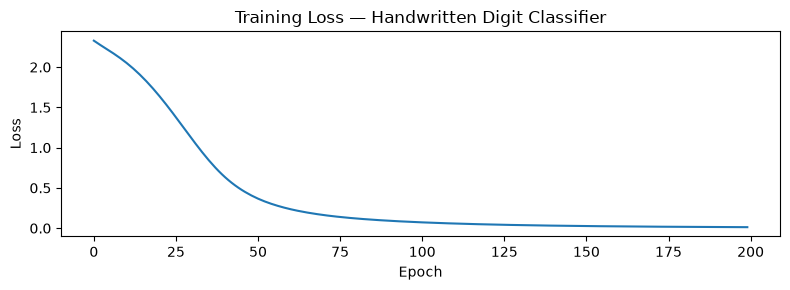

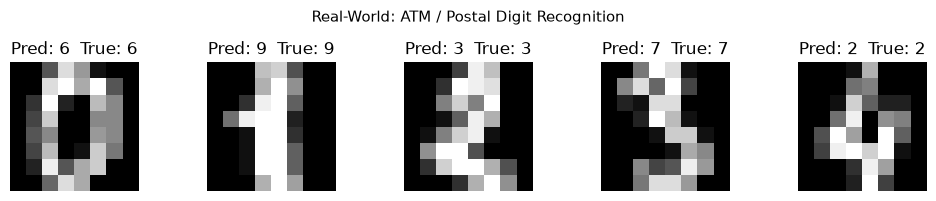

In [4]:
import torch, torch.nn as nn, torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np, matplotlib.pyplot as plt

# ── Real digit images (1797 samples, 8×8 pixels) ──────────────────────────
digits = load_digits()
X = StandardScaler().fit_transform(digits.data.astype(np.float32))
y = digits.target

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr_t = torch.tensor(X_tr)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te)
y_te_t = torch.tensor(y_te, dtype=torch.long)

# ── Two-layer neural network ───────────────────────────────────────────────
model = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.CrossEntropyLoss()
losses    = []

for epoch in range(200):
    model.train()
    pred = model(X_tr_t)
    loss = loss_fn(pred, y_tr_t)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())

# ── Evaluation ──────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    acc = (model(X_te_t).argmax(1) == y_te_t).float().mean().item()

print(f"Test accuracy on real handwritten digits: {acc*100:.1f}%")

# ── Plot training loss ───────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title("Training Loss — Handwritten Digit Classifier"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout(); plt.show()

# ── Show a sample prediction ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    pred_lbl = model(torch.tensor(X_te[:5])).argmax(1)[i].item()
    ax.set_title(f"Pred: {pred_lbl}  True: {y_te[i]}")
    ax.axis('off')
plt.suptitle("Real-World: ATM / Postal Digit Recognition", fontsize=11)
plt.tight_layout(); plt.show()

## 🧩 Mini-exercise 

**Try it (choose one):**
- Change `n_subset` (e.g. from 5000 to 2000 or 10000) and run the notebook again. How does test accuracy change for the NN and for logistic regression?
- Add one more Dense layer (e.g. 64 units, ReLU) to the NN, then retrain. Does accuracy improve?

*Add a new code cell below, make the change, run it, and compare. Then continue to the Summary.*

---

## ✅ Summary 

**What you did:**
- Trained a small NN and logistic regression on the same MNIST subset.
- Compared test accuracy; the NN usually does better on raw pixels because it learns non-linear features.

**In real life you'd also:** Use validation sets, tune hyperparameters, and for traditional ML you might engineer image features (e.g. HOG) and then use LR.

**The main idea:** Deep learning learns features from raw data; traditional ML often relies on hand-designed features. For raw images, a NN typically outperforms a linear model on pixels.

**Next:** `02_simple_neural_network` builds the NN step by step; `03_perceptron_mlp_tensorflow_pytorch_setup` shows perceptron and MLP in TF/PyTorch.

## 📚 References & Further Reading

**Foundational Papers:**
- LeCun, Bengio & Hinton (2015) — [Deep Learning](https://www.nature.com/articles/nature14539), *Nature*
- Goodfellow et al. (2016) — [Deep Learning Book](https://www.deeplearningbook.org/) (free online)

**PyTorch Docs:**
- [torch.nn — Building Blocks](https://pytorch.org/docs/stable/nn.html)
- [Autograd — Automatic Differentiation](https://pytorch.org/docs/stable/autograd.html)

**State-of-the-Art (2024–2025):**
- Transformers (GPT-4, LLaMA 3) are deep networks with 70B+ parameters
- Deep learning powers real-time translation, medical diagnosis, self-driving cars